In [2]:
import sys
sys.path.append('/opt/software/root/6.36.00/lib')


In [3]:
#!pip install uproot
from ROOT import TFile, TTree, std
import ROOT
import matplotlib.pyplot as plt
import glob
import pickle as pkl
import numpy as np
import tqdm
import os
import math
from collections import Counter, defaultdict

In [3]:
base_path = "/scratch2/libota/SFGD_Vertex_Activity/Data/HighLand_output"
save_base_path = '/scratch2/libota/SFGD_Vertex_Activity/Data/HighLand_output/NN_Data'

muon_path = base_path + "/Muon_0to2.5GeVc/output_PGun_muon_1by1cube_1.027cm_0to2.5GeV.root"
proton_contained_path = base_path + "/Proton_0to450MeVc/output_PGun_proton_1by1cube_1.027cm_0to450MeV.root"
proton_exiting_path = base_path + "/Proton_0to1500MeVc/output_PGun_proton_1by1cube_1.027cm_0to1500MeV.root"



proton_contained_file = TFile(proton_contained_path, "read")
proton_exiting_file = TFile(proton_exiting_path, "read")
proton_contained_file.ls()
proton_exiting_file.ls()

muon_file = TFile(muon_path, "read")
muon_file.ls()

TFile**		/scratch2/libota/SFGD_Vertex_Activity/Data/HighLand_output/Proton_0to450MeVc/output_PGun_proton_1by1cube_1.027cm_0to450MeV.root	
 TFile*		/scratch2/libota/SFGD_Vertex_Activity/Data/HighLand_output/Proton_0to450MeVc/output_PGun_proton_1by1cube_1.027cm_0to450MeV.root	
  KEY: TTree	ana;1	20
  KEY: TTree	truth;1	2
  KEY: TTree	config;1	0
  KEY: TTree	header;1	1
TFile**		/scratch2/libota/SFGD_Vertex_Activity/Data/HighLand_output/Proton_0to1500MeVc/output_PGun_proton_1by1cube_1.027cm_0to1500MeV.root	
 TFile*		/scratch2/libota/SFGD_Vertex_Activity/Data/HighLand_output/Proton_0to1500MeVc/output_PGun_proton_1by1cube_1.027cm_0to1500MeV.root	
  KEY: TTree	ana;1	20
  KEY: TTree	truth;1	2
  KEY: TTree	config;1	0
  KEY: TTree	header;1	1
TFile**		/scratch2/libota/SFGD_Vertex_Activity/Data/HighLand_output/Muon_0to2.5GeVc/output_PGun_muon_1by1cube_1.027cm_0to2.5GeV.root	
 TFile*		/scratch2/libota/SFGD_Vertex_Activity/Data/HighLand_output/Muon_0to2.5GeVc/output_PGun_muon_1by1cube_1.027cm_0to2.5

Warning in <TClass::Init>: no dictionary for class PackageVersion is available
Warning in <TClass::Init>: no dictionary for class TrackCategoryDefinition is available
Warning in <TClass::Init>: no dictionary for class TrackTypeDefinition is available
Warning in <TClass::Init>: no dictionary for class SelectionBase is available
Warning in <TClass::Init>: no dictionary for class StepBase is available
Warning in <TClass::Init>: no dictionary for class DocString is available
Warning in <TClass::Init>: no dictionary for class ConfigurationBase is available
Warning in <TClass::Init>: no dictionary for class ToyVariationWrite is available
Warning in <TClass::Init>: no dictionary for class SystematicBase is available
Warning in <TClass::Init>: no dictionary for class CorrectionBase is available
Warning in <TClass::Init>: no dictionary for class Header is available


In [4]:
def particleToType(particle):
    if particle == 'proton_contained' or particle == 'proton_exiting':
        return 0
    elif particle == 'muon':
        return 1
    else:
        return 2

In [5]:
ana_proton_contained_tree = proton_contained_file["ana"]
ana_proton_exiting_tree = proton_exiting_file["ana"]
ana_muon_tree = muon_file["ana"]
trees = {'proton_contained': ana_proton_contained_tree, 'proton_exiting': ana_proton_exiting_tree, 'muon': ana_muon_tree}
#ana_proton_tree.Print()
#ana_muon_tree.Print()

In [23]:
7//2

3

In [4]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_voxels(x, y, z, values, cmap='viridis', eps=1e-6):
    """
    Plot non-empty voxels in a 9×9×9 grid with opacity scaled logarithmically.

    Parameters:
    - x, y, z: sequences of relative positions in [-4, 4].
    - values: sequence of the same length as x, y, z containing positive scalar values.
    - cmap: colormap name for mapping values to colors.
    - eps: small offset added to values to avoid log(0) issues.
    """
    # Convert positions to 0–8 index space
    x_idx = np.array(x, int) + 4
    y_idx = np.array(y, int) + 4
    z_idx = np.array(z, int) + 4
    vals = np.array(values, float)
    
    # Offset to ensure positivity for log
    vals_offset = vals + eps
    
    # Compute log-scaled values and normalize
    log_vals = np.log(vals_offset)
    norm_color = plt.Normalize(vals.min(), vals.max())
    norm_alpha = plt.Normalize(log_vals.min(), log_vals.max())
    cmap_obj = plt.cm.get_cmap(cmap)
    
    # Prepare masks and color array (RGBA)
    mask = np.zeros((9, 9, 9), bool)
    colors = np.zeros((9, 9, 9, 4), float)
    
    for xi, yi, zi, v, lv in zip(x_idx, y_idx, z_idx, vals, log_vals):
        mask[xi, yi, zi] = True
        r, g, b, _ = cmap_obj(norm_color(v))
        a = norm_alpha(lv)
        colors[xi, yi, zi] = (r, g, b, a)
    
    # Plot
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.voxels(mask, facecolors=colors, edgecolor='k')
    
    ax.set_xticks(range(9))
    ax.set_yticks(range(9))
    ax.set_zticks(range(9))
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('9×9×9 Voxel Plot with Log-Scaled Opacity')
    plt.show()

import numpy as np
import plotly.graph_objects as go
from matplotlib import cm, colors

def plot_voxels_plotly(x, y, z, values, cmap='viridis', eps=1e-6):
    """
    Plot non-empty voxels in a 9×9×9 grid using Plotly mesh3d,
    with opacity scaled by the square root of each value and
    an added colorbar.
    
    Parameters:
    - x, y, z: sequences of relative positions in [-4, 4].
    - values: sequence of the same length containing scalar values.
    - cmap: Matplotlib colormap name for mapping values to colors.
    - eps: small offset to avoid sqrt(0) issues.
    """
    xi = np.array(x, int) + 4
    yi = np.array(y, int) + 4
    zi = np.array(z, int) + 4
    vals = np.array(values, float)

    sqrt_vals = np.sqrt(vals + eps)
    sv_min, sv_max = sqrt_vals.min(), sqrt_vals.max()
    v_min, v_max = vals.min(), vals.max()

    cube_verts = np.array([[-0.5,-0.5,-0.5],[0.5,-0.5,-0.5],[0.5,0.5,-0.5],[-0.5,0.5,-0.5],
                           [-0.5,-0.5, 0.5],[0.5,-0.5, 0.5],[0.5,0.5, 0.5],[-0.5,0.5, 0.5]])
    faces = np.array([[0,1,2],[0,2,3],[4,5,6],[4,6,7],
                      [0,1,5],[0,5,4],[2,3,7],[2,7,6],
                      [0,3,7],[0,7,4],[1,2,6],[1,6,5]])

    Xs, Ys, Zs = [], [], []
    I, J, K = [], [], []
    face_colors = []
    vert_count = 0

    cmap_obj = matplotlib.colormaps[cmap]
    norm_color = colors.Normalize(vmin=v_min, vmax=v_max)

    for x0, y0, z0, v, sv in zip(xi, yi, zi, vals, sqrt_vals):
        verts = cube_verts + np.array([x0, y0, z0])
        Xs.extend(verts[:,0]); Ys.extend(verts[:,1]); Zs.extend(verts[:,2])
        for tri in faces:
            I.append(vert_count + tri[0])
            J.append(vert_count + tri[1])
            K.append(vert_count + tri[2])
        r, g, b, _ = cmap_obj(norm_color(v))
        r, g, b = int(r*255), int(g*255), int(b*255)
        frac_sv = (sv - sv_min) / (sv_max - sv_min) if sv_max > sv_min else 1.0
        a = frac_sv * 0.8 + 0.2  # map to [0.2, 1]
        rgba = f'rgba({r},{g},{b},{a})'
        face_colors += [rgba] * len(faces)
        vert_count += len(verts)

    mesh = go.Mesh3d(
        x=Xs, y=Ys, z=Zs,
        i=I, j=J, k=K,
        facecolor=face_colors,
        flatshading=True,
        showscale=False
    )

    colorbar = go.Scatter3d(
        x=[None], y=[None], z=[None],
        mode='markers',
        marker=dict(
            colorscale=cmap,
            cmin=v_min,
            cmax=v_max,
            color=[v_min, v_max],
            showscale=True,
            colorbar=dict(title='Value')
        ),
        hoverinfo='none'
    )

    fig = go.Figure(data=[mesh, colorbar])
    fig.update_layout(
        scene=dict(
            xaxis=dict(nticks=10, range=[0, 9]),
            yaxis=dict(nticks=10, range=[0, 9]),
            zaxis=dict(nticks=10, range=[0, 9]),
            aspectmode='cube'
        ),
        title='9×9×9 grid'
    )
    fig.show()


In [9]:
eps = 1e-12
cube_size = 10.27
bins = 50
folder_size = 100_000
bin_edges = np.linspace(start=0, stop=cube_size, num=bins + 1, endpoint=True)
grid_size = 9
lo, hi = -(grid_size//2), grid_size//2
save_path = save_base_path + '/{}/{}/{}'

true_inip_counter    = Counter()
true_iniekin_counter = Counter()
recon_p_counter         = Counter()
recon_ekin_counter      = Counter()
recon_nhit_counter   = Counter()
recon_charge_counter = Counter()
dir_sum = np.zeros(3, dtype=np.float64)
dir_count = 0
per_tree_true_inip     = defaultdict(Counter)
per_tree_true_iniekin  = defaultdict(Counter)
per_tree_recon_p        = defaultdict(Counter)
per_tree_recon_ekin     = defaultdict(Counter)
per_tree_nhit   = defaultdict(Counter)
per_tree_charge = defaultdict(Counter)
metadata = {}
lookup_tables = {}
nan_counts = {}
exiting_counts = {}
contained_counts = {}
empty_counts   = {}
negative_src_pos_counts = {}

def has_bad(x):
    # returns True if x is NaN or ±Inf anywhere
    arr = np.asarray(x, dtype=float)
    return not np.all(np.isfinite(arr))

for key, tree in trees.items():

    n_selected = 0
    total_entries = tree.GetEntries()
    lookup_table = {}
    event_id, exiting, contained, empty, nan, negative_src_pos = 0, 0, 0, 0, 0, 0
    tree_true_inip    = Counter()
    tree_true_iniekin = Counter()
    tree_recon_p        = Counter()
    tree_recon_ekin     = Counter()
    tree_nhit         = Counter()
    tree_charge       = Counter()

    print("-----{}-----".format(key))
    print(total_entries)
    t = tqdm.tqdm(range(total_entries), total=total_entries, disable=True)
    for entry_idx in t:
        if entry_idx%2000 == 0:
            print("Processing entry {}".format(entry_idx))

        if (n_selected+1)%20000 == 0:
            print("{} selected in {}/{}".format(n_selected, entry_idx, total_entries))
            #break
        tree.GetEntry(entry_idx)

        # truth info
        run_number = tree.run
        subrun_number = tree.subrun
        evt_number = tree.evt
        particle_type = particleToType(key)
        true_inipos = np.array(tree.true_inipos)[:3]
        true_inipos_mod = np.array(tree.true_inipos_mod)[:3]  # [0, cube_size]
        true_endpos = np.array(tree.true_endpos)[:3]
        true_inidir = np.array(tree.true_inidir)
        true_inip = tree.true_inip
        true_iniekin = tree.true_iniekin
        true_sfg_con = tree.true_sfg_con

        # recon info
        recon_obj_type = tree.recon_obj_type  # 1: primary track; 2: cluster; 3: non-primary track
        recon_sfg_con = tree.recon_sfg_con
        recon_exit_tag = tree.recon_exit_tag  # 0: contained VA; 1: escaping VA
        recon_inipos = np.array(tree.recon_inipos)[:3]
        recon_inidir = np.array(tree.recon_inidir)[:3]
        recon_p = tree.recon_p
        recon_ekin = tree.recon_Ekin
        recon_sfg_nhit = tree.recon_sfg_nhit
        recon_sfg_hitposx_rel = np.array(tree.recon_sfg_hitposx_rel)
        recon_sfg_hitposy_rel = np.array(tree.recon_sfg_hitposy_rel)
        recon_sfg_hitposz_rel = np.array(tree.recon_sfg_hitposz_rel)
        recon_sfg_charge = np.array(tree.recon_sfg_charge)

        # collect _all_ of your tree outputs—scalars and arrays
        to_check = [
            particle_type,
            true_inip,
            true_iniekin,
            true_sfg_con,
            recon_obj_type,
            recon_sfg_con,
            recon_exit_tag,
            recon_p,
            recon_ekin,
            # the 3-vectors
            true_inipos,
            true_inipos_mod,
            true_endpos,
            true_inidir,
            recon_inipos,
            recon_inidir,
            # the hit-position and charge arrays
            recon_sfg_hitposx_rel,
            recon_sfg_hitposy_rel,
            recon_sfg_hitposz_rel,
            recon_sfg_charge,
        ]
        
        if recon_sfg_nhit <= 0:
            empty += 1
            continue
            
        # if any entry is NaN or Inf, skip it
        if any(has_bad(x) for x in to_check) or (recon_sfg_charge.min() < 0) or (recon_p < 0) or (recon_ekin < 0):
            nan += 1
            continue
        
        if (recon_exit_tag == 1 or true_sfg_con == 0):
            exiting += 1
            assert any([np.abs(recon_sfg_hitposx_rel).max() >= 4, 
                        np.abs(recon_sfg_hitposy_rel).max() >= 4, 
                        np.abs(recon_sfg_hitposz_rel).max() >= 4]
                      )
            if "proton_contained" == key:
                # keep only contained protons
                continue

        else:
            contained += 1
            if "muon" == key or "proton_exiting" == key:
                # keep only escaping muons
                continue
        
        n_selected += 1

        #assert (true_inipos_mod >= 0).all() and (true_inipos_mod<=cube_size).all()
        if (true_inipos_mod < 0).any() or (true_inipos_mod > cube_size).any():
            negative_src_pos += 1
            continue
        assert np.isclose(np.linalg.norm(true_inidir), 1.0, atol=1e-5)

        # filter out exiting points
        mask = (
            (recon_sfg_hitposx_rel >= lo) & (recon_sfg_hitposx_rel <= hi) &
            (recon_sfg_hitposy_rel >= lo) & (recon_sfg_hitposy_rel <= hi) &
            (recon_sfg_hitposz_rel >= lo) & (recon_sfg_hitposz_rel <= hi)
        )
        recon_sfg_hitposx_rel = recon_sfg_hitposx_rel[mask]
        recon_sfg_hitposy_rel = recon_sfg_hitposy_rel[mask]
        recon_sfg_hitposz_rel = recon_sfg_hitposz_rel[mask]
        recon_sfg_charge = recon_sfg_charge[mask]

        # accumulate into global counters
        true_inip_counter[int(true_inip)]       += 1
        true_iniekin_counter[int(true_iniekin)] += 1
        recon_p_counter[int(recon_p)]           += 1
        recon_ekin_counter[int(recon_ekin)]     += 1
        recon_nhit_counter[int(recon_sfg_nhit)] += 1
        tree_true_inip[int(true_inip)]          += 1
        tree_true_iniekin[int(true_iniekin)]    += 1
        tree_recon_p[int(recon_p)]              += 1
        tree_recon_ekin[int(recon_ekin)]        += 1
        tree_nhit[int(recon_sfg_nhit)]          += 1
        for q in recon_sfg_charge:
            qi = int(q)
            recon_charge_counter[qi] += 1
            tree_charge[qi]+= 1
        dir_sum += true_inidir
        dir_count += 1
    
        # retrieve the bin of each pos
        bin_indices = np.digitize(true_inipos_mod, bin_edges, right=False)
        bin_indices = tuple(bin_indices)
        lookup_table.setdefault(bin_indices, []).append(event_id)

        assert True

        folder_index = event_id // folder_size
        filename = save_path.format(key, folder_index, event_id) + ".npz"
        os.makedirs(os.path.dirname(filename), exist_ok=True)
        np.savez_compressed(filename,
                        run_number = run_number,
                        subrun_number = subrun_number,
                        evt_number = evt_number,
                        particle_type = particle_type,
                        true_inipos_mod = true_inipos_mod,
                        true_inipos = true_inipos,
                        true_endpos = true_endpos,
                        true_inidir = true_inidir,
                        true_inip = true_inip,
                        true_iniekin = true_iniekin,
                        true_sfg_con = true_sfg_con,
                        recon_obj_type = recon_obj_type,
                        recon_sfg_con = recon_sfg_con,
                        recon_exit_tag = recon_exit_tag,
                        recon_sfg_nhit = recon_sfg_nhit,
                        recon_inipos = recon_inipos,
                        recon_inidir = recon_inidir,
                        recon_p = recon_p,
                        recon_ekin = recon_ekin,
                        recon_sfg_hitposx_rel = recon_sfg_hitposx_rel,
                        recon_sfg_hitposy_rel = recon_sfg_hitposy_rel,
                        recon_sfg_hitposz_rel = recon_sfg_hitposz_rel,
                        recon_sfg_charge = recon_sfg_charge,

                       )
        event_id += 1
    
    lookup_tables[key] = lookup_table
    nan_counts[key] = nan
    exiting_counts[key] = exiting
    contained_counts[key] = contained
    empty_counts[key]   = empty
    negative_src_pos_counts[key] = negative_src_pos
    per_tree_true_inip[key]    = tree_true_inip
    per_tree_true_iniekin[key] = tree_true_iniekin
    per_tree_recon_p[key]        = tree_recon_p
    per_tree_recon_ekin[key]     = tree_recon_ekin
    per_tree_nhit[key]   = tree_nhit
    per_tree_charge[key] = tree_charge


-----proton_contained-----
7846037
Processing entry 0
Processing entry 2000
Processing entry 4000
Processing entry 6000
Processing entry 8000
Processing entry 10000
Processing entry 12000
Processing entry 14000
Processing entry 16000
Processing entry 18000
Processing entry 20000
Processing entry 22000
Processing entry 24000
Processing entry 26000
19999 selected in 27205/7846037
19999 selected in 27206/7846037
19999 selected in 27207/7846037
19999 selected in 27208/7846037
Processing entry 28000
Processing entry 30000
Processing entry 32000
Processing entry 34000
Processing entry 36000
Processing entry 38000
Processing entry 40000
Processing entry 42000
Processing entry 44000
Processing entry 46000
Processing entry 48000
Processing entry 50000
Processing entry 52000
Processing entry 54000
39999 selected in 54545/7846037
Processing entry 56000
Processing entry 58000
Processing entry 60000
Processing entry 62000
Processing entry 64000
Processing entry 66000
Processing entry 68000
Processi

In [10]:
def compute_stats(cnt: Counter):
    total = sum(cnt.values())
    if total == 0:
        return dict(mean=0, median=0, std=0, min=0, max=0)
    mean  = sum(v*c for v,c in cnt.items())/total
    var   = sum((v**2)*c for v,c in cnt.items())/total - mean**2
    std   = np.sqrt(var)
    cum = 0
    median = None
    for v in sorted(cnt):
        cum += cnt[v]
        if cum >= total/2:
            median = v
            break
    return dict(mean=mean, median=median, std=std, min=min(cnt), max=max(cnt))

def with_trans(fn, stats):
    return {k: fn(v) for k,v in stats.items()}

statistics = {}

for name, cnt in [
    ('true_inip',    true_inip_counter),
    ('true_iniekin', true_iniekin_counter),
    ('recon_p',      recon_p_counter),
    ('recon_ekin',   recon_ekin_counter),
    ('recon_nhit',   recon_nhit_counter),
    ('recon_charge', recon_charge_counter),
]:
    print(name)
    base = compute_stats(cnt)
    statistics[name]            = base
    statistics[f"{name}_log1p"] = with_trans(np.log1p, base)
    statistics[f"{name}_sqrt"]  = with_trans(np.sqrt,  base)

statistics['true_inidir_mean'] = (dir_sum/dir_count).tolist()

statistics['per_tree'] = {}
for key in trees:
    statistics['per_tree'][key] = {
        'true_inip':       compute_stats(per_tree_true_inip[key]),
        'true_inip_log1p': with_trans(np.log1p, compute_stats(per_tree_true_inip[key])),
        'true_inip_sqrt':  with_trans(np.sqrt,  compute_stats(per_tree_true_inip[key])),
        'true_iniekin':       compute_stats(per_tree_true_iniekin[key]),
        'true_iniekin_log1p': with_trans(np.log1p, compute_stats(per_tree_true_iniekin[key])),
        'true_iniekin_sqrt':  with_trans(np.sqrt,  compute_stats(per_tree_true_iniekin[key])),
        'recon_p':          compute_stats(per_tree_recon_p[key]),
        'recon_p_log1p':    with_trans(np.log1p, compute_stats(per_tree_recon_p[key])),
        'recon_p_sqrt':     with_trans(np.sqrt,  compute_stats(per_tree_recon_p[key])),
        'recon_ekin':       compute_stats(per_tree_recon_ekin[key]),
        'recon_ekin_log1p': with_trans(np.log1p, compute_stats(per_tree_recon_ekin[key])),
        'recon_ekin_sqrt':  with_trans(np.sqrt,  compute_stats(per_tree_recon_ekin[key])),
        'recon_nhit':       compute_stats(per_tree_nhit[key]),
        'recon_nhit_log1p': with_trans(np.log1p, compute_stats(per_tree_nhit[key])),
        'recon_nhit_sqrt':  with_trans(np.sqrt,  compute_stats(per_tree_nhit[key])),
        'recon_charge':     compute_stats(per_tree_charge[key]),
        'recon_charge_log1p': with_trans(np.log1p, compute_stats(per_tree_charge[key])),
        'recon_charge_sqrt':  with_trans(np.sqrt,  compute_stats(per_tree_charge[key])),
    }

# attach into metadata and dump
metadata.update({
    'lookup_tables': lookup_tables,
    'nan':           nan_counts,
    'exiting':       exiting_counts,
    'contained':     contained_counts,
    'empty':         empty_counts,
    'negative_src_pos': negative_src_pos_counts,
    'statistics':    statistics,
})

with open(os.path.join(save_base_path, "metadata.pkl"), "wb") as fd:
    pkl.dump(metadata, fd)




true_inip
true_iniekin
recon_p
recon_ekin
recon_nhit
recon_charge


dict_keys(['lookup_tables', 'nan', 'exiting', 'contained', 'empty', 'negative_src_pos', 'statistics'])
3862889
125000
{'true_inip': {'mean': 766.0337917191523, 'median': 492, 'std': np.float64(617.5981599561136), 'min': 0, 'max': 2499}, 'true_inip_log1p': {'mean': np.float64(6.642530857396974), 'median': np.float64(6.20050917404269), 'std': np.float64(6.427455885717146), 'min': np.float64(0.0), 'max': np.float64(7.824046010856292)}, 'true_inip_sqrt': {'mean': np.float64(27.67731547168461), 'median': np.float64(22.181073012818835), 'std': np.float64(24.851522286494113), 'min': np.float64(0.0), 'max': np.float64(49.98999899979995)}, 'true_iniekin': {'mean': 491.41085905375303, 'median': 190, 'std': np.float64(624.5043991930643), 'min': 0, 'max': 2395}, 'true_iniekin_log1p': {'mean': np.float64(6.199313447385066), 'median': np.float64(5.25227342804663), 'std': np.float64(6.43855836296467), 'min': np.float64(0.0), 'max': np.float64(7.78155595923534)}, 'true_iniekin_sqrt': {'mean': np.float

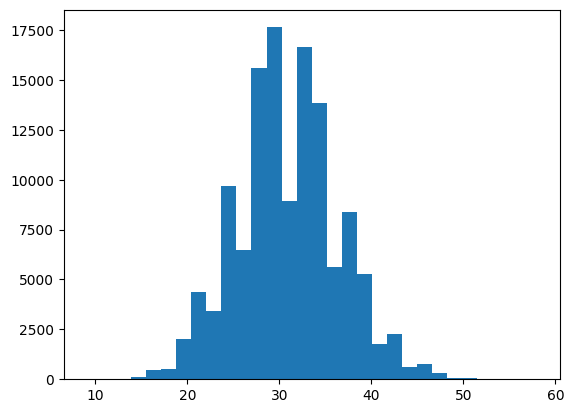

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
save_base_path = '/scratch/libota/sfgd_va_nn_data/NN_Data'
df = pd.read_pickle(save_base_path + "/metadata.pkl")
print(df.keys())

# number of muons in the dataset
print(df['exiting']['muon'])
print(df['exiting']['proton_exiting'])
print(df['contained']['proton_contained'])


key = list(df['lookup_tables']['proton_exiting'].keys())
print(len(key))

print(df['statistics'])

#Draw a histogram of the length of each key in lookup_tables
values = []
for key, value in df['lookup_tables']['muon'].items():
    values.append(len(value))
values = np.array(values)
plt.hist(values, bins=30)
plt.show()



In [17]:
# event display example
print(true_iniekin, recon_exit_tag)
plot_voxels_plotly(recon_sfg_hitposx_rel, recon_sfg_hitposy_rel, recon_sfg_hitposz_rel, recon_sfg_charge)

1741.9849853515625 1


In [22]:
particle = "proton_exiting"
folder_index = 0
event_id = 5100
save_path = "/scratch/libota/sfgd_va_nn_data/NN_Data/{}/{}/{}.npz"
filename = save_path.format(particle, folder_index, event_id)
# read the npz file
data = np.load(filename)
print(data.keys())

x = data['recon_sfg_hitposx_rel']
y = data['recon_sfg_hitposy_rel']
z = data['recon_sfg_hitposz_rel']
charge = data['recon_sfg_charge']

plot_voxels_plotly(x, y, z, charge)


KeysView(NpzFile '/scratch/libota/sfgd_va_nn_data/NN_Data/proton_exiting/0/5100.npz' with keys: run_number, subrun_number, evt_number, particle_type, true_inipos_mod...)


In [ ]:
with open(os.path.join(save_base_path, "metadata.pkl"), "rb") as fd:
    metadata = pkl.load(fd)

In [ ]:
# check distribution of "subcubes"
values = []
for key, value in metadata['lookup_tables']['proton'].items():
    if len(value) < 10:
        print(key, len(value))
    values.append(len(value))
values = np.array(values)

plt.hist(values, bins=30)
plt.show()